HOUSE PRICE PRIDICTION PROJECT

--Project Overview

This project aims to predict house prices using historical data.
The goal is to build regression models, analyze important features, and evaluate model performance.
    
We will follow these steps:
1. Data Loading and Inspection
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Model Building and Evaluation
5. Conclusion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

--Load the Dataset.

Load the dataset and inspect the first few rows to understand the structure, columns and the type of features.

In [2]:
df=pd.read_csv("house_cleaned.csv")
df.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,5 Bedroom House for sale in Sector 70A Gurgaon,house,bptp visionnaire,5.25,20115.0,2610.0,Plot area 290(242.48 sq.m.),5,4,3+,servant room,"29b, Sector 70A Gurgaon, Gurgaon, Haryana",3.0,North-East,0 to 1 Year Old,"['Good Earth City Center 2', 'Kunskapsskolan I...",Do you wish to buy an independent house in sec...,"['1 Wardrobe', '1 Fan', '1 Exhaust Fan', '1 Ge...","['Feng Shui / Vaastu Compliant', 'Private Gard...","['Environment5 out of 5', 'Lifestyle4 out of 5..."
1,5 Bedroom House for sale in Sector 21A Faridabad,house,independent,5.70,105751.0,539.0,Plot area 539(50.07 sq.m.),5,4,2,"store room,pooja room,servant room","Sector 21A Faridabad, Gurgaon, Haryana",2.0,NaN,5 to 10 Year Old,NaN,"Hi, we have an independent house/villa availab...","['1 Water Purifier', '5 Fan', '1 Exhaust Fan',...","['Private Garden / Terrace', 'Park', 'Visitor ...",NaN
2,10 Bedroom House for sale in Sushant Lok Phase 1,house,independent,2.10,38251.0,549.0,Plot area 61(51 sq.m.),10,10,3+,servant room,"Sushant Lok Phase 1, Gurgaon, Haryana",5.0,West,0 to 1 Year Old,"['Sector 42-43 metro station', 'Huda city cent...","Monthly rental income is rs1,40,000/- Best opt...","['10 Bed', '3 Fan', '10 Geyser', '2 Light', 'N...","['Maintenance Staff', 'Water Storage', 'Visito...","['Environment5 out of 5', 'Lifestyle5 out of 5..."
3,21 Bedroom House for sale in Sector 54 Gurgaon,house,independent,5.00,43066.0,1161.0,Plot area 129(107.86 sq.m.),21,21,3+,servant room,"Sector 54 Gurgaon, Gurgaon, Haryana",5.0,North,1 to 5 Year Old,"['Sector 53-54 metro station', 'Sector 54 chow...","129 sq yd plot size. 5 floors built up , fully...","['1 Water Purifier', '21 Fan', '1 Fridge', '1 ...","['Feng Shui / Vaastu Compliant', 'Private Gard...","['Environment4 out of 5', 'Lifestyle5 out of 5..."
4,12 Bedroom House for sale in Sushant Lok Phase 1,house,independent,3.00,53763.0,558.0,Plot area 62(51.84 sq.m.),12,12,3+,others,"1228, Sushant Lok Phase 1, Gurgaon, Haryana",5.0,West,Within 6 months,"['Sector 42-43 metro station', 'Huda city cent...",Best for investment purpose. Fully furnished b...,"['1 Water Purifier', '1 Fridge', '12 Fan', '1 ...","['Maintenance Staff', 'Water Storage', 'Visito...","['Environment5 out of 5', 'Lifestyle5 out of 5..."


In [3]:
#Total number of rows and columns

df.shape

(964, 20)

In [4]:
# Information of the data present

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 964 entries, 0 to 963
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   property_name    964 non-null    object 
 1   property_type    964 non-null    object 
 2   society          964 non-null    object 
 3   price            945 non-null    float64
 4   price_per_sqft   945 non-null    float64
 5   area             945 non-null    float64
 6   areaWithType     964 non-null    object 
 7   bedRoom          964 non-null    int64  
 8   bathroom         964 non-null    int64  
 9   balcony          964 non-null    object 
 10  additionalRoom   964 non-null    object 
 11  address          959 non-null    object 
 12  floorNum         945 non-null    float64
 13  facing           661 non-null    object 
 14  agePossession    964 non-null    object 
 15  nearbyLocations  848 non-null    object 
 16  description      964 non-null    object 
 17  furnishDetails  

In [5]:
#Description of count, mean, min, max etc of each numeric column

df.describe()

,price,price_per_sqft,area,bedRoom,bathroom,floorNum
count,945.000000,945.000000,9.450000e+02,964.000000,964.000000,945.000000
mean,4.911069,28251.213757,1.055610e+04,5.117220,4.825726,2.759788
std,4.651008,42849.177326,2.359139e+05,3.253843,3.350535,2.923544
min,0.070000,2.000000,4.500000e+01,1.000000,1.000000,0.000000
25%,1.200000,10085.000000,9.500000e+02,3.000000,3.000000,2.000000
50%,3.600000,19231.000000,1.809000e+03,4.000000,4.000000,2.000000
75%,7.000000,30247.000000,3.191000e+03,6.000000,6.000000,3.000000
max,31.500000,600000.000000,7.250000e+06,36.000000,36.000000,51.000000


In [6]:
#Check null values

df.isnull().sum().sort_values(ascending=False)

facing             303
features           302
furnishDetails     235
rating             121
nearbyLocations    116
price_per_sqft      19
floorNum            19
price               19
area                19
address              5
property_name        0
property_type        0
society              0
additionalRoom       0
bathroom             0
bedRoom              0
areaWithType         0
balcony              0
agePossession        0
description          0
dtype: int64

In [7]:
#Filling the null values

df.fillna(df.median(numeric_only=True),inplace=True)

In [8]:
#Sort the values in ascending values

df.isnull().sum().sort_values(ascending=False)

facing             303
features           302
furnishDetails     235
rating             121
nearbyLocations    116
address              5
property_type        0
property_name        0
price                0
society              0
areaWithType         0
price_per_sqft       0
additionalRoom       0
balcony              0
bathroom             0
bedRoom              0
area                 0
floorNum             0
agePossession        0
description          0
dtype: int64

In [9]:
#Find the datatype

df["rating"].dtype

dtype('O')

In [10]:
#Shows each row from the rating column which has both numeric and categorical dtype

df["rating"].value_counts()

rating
['Environment5 out of 5', 'Lifestyle5 out of 5', 'Connectivity5 out of 5', 'Safety5 out of 5']          125
['Environment4 out of 5', 'Lifestyle4 out of 5', 'Connectivity5 out of 5', 'Safety4 out of 5']          112
['Environment4 out of 5', 'Lifestyle4 out of 5', 'Connectivity4 out of 5', 'Safety4 out of 5']          112
['Environment5 out of 5', 'Safety5 out of 5', 'Lifestyle5 out of 5', 'Connectivity5 out of 5']           54
['Environment4 out of 5', 'Lifestyle5 out of 5', 'Connectivity5 out of 5', 'Safety4 out of 5']           47
                                                                                                       ... 
['Environment4 out of 5', 'Safety4 out of 5', 'Lifestyle4.5 out of 5', 'Connectivity4 out of 5']          1
['Environment4.5 out of 5', 'Safety4.5 out of 5', 'Lifestyle4 out of 5', 'Connectivity3.5 out of 5']      1
['Environment5 out of 5', 'Safety5 out of 5', 'Lifestyle4.5 out of 5', 'Connectivity5 out of 5']          1
['Environment4.5 out 

In [11]:
#Replacing it with numeric values

df["rating"].fillna(df["rating"].mode()[0], inplace=True)

In [12]:
#Filling more columns

df["facing"].fillna("UnKnown",inplace=True)
df["furnishDetails"].fillna("NotMentioned",inplace=True)
df["nearbyLocations"].fillna("UnKnown",inplace=True)
df["address"].fillna("UnKnown",inplace=True)                   

In [13]:
#Dropping the column(delete)

df.drop("features", axis=1, inplace=True)

In [14]:
#Checking the null values again

df.isnull().sum().sort_values(ascending=False)

property_name      0
property_type      0
society            0
price              0
price_per_sqft     0
area               0
areaWithType       0
bedRoom            0
bathroom           0
balcony            0
additionalRoom     0
address            0
floorNum           0
facing             0
agePossession      0
nearbyLocations    0
description        0
furnishDetails     0
rating             0
dtype: int64

In [15]:
df.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,rating
0,5 Bedroom House for sale in Sector 70A Gurgaon,house,bptp visionnaire,5.25,20115.0,2610.0,Plot area 290(242.48 sq.m.),5,4,3+,servant room,"29b, Sector 70A Gurgaon, Gurgaon, Haryana",3.0,North-East,0 to 1 Year Old,"['Good Earth City Center 2', 'Kunskapsskolan I...",Do you wish to buy an independent house in sec...,"['1 Wardrobe', '1 Fan', '1 Exhaust Fan', '1 Ge...","['Environment5 out of 5', 'Lifestyle4 out of 5..."
1,5 Bedroom House for sale in Sector 21A Faridabad,house,independent,5.70,105751.0,539.0,Plot area 539(50.07 sq.m.),5,4,2,"store room,pooja room,servant room","Sector 21A Faridabad, Gurgaon, Haryana",2.0,UnKnown,5 to 10 Year Old,UnKnown,"Hi, we have an independent house/villa availab...","['1 Water Purifier', '5 Fan', '1 Exhaust Fan',...","['Environment5 out of 5', 'Lifestyle5 out of 5..."
2,10 Bedroom House for sale in Sushant Lok Phase 1,house,independent,2.10,38251.0,549.0,Plot area 61(51 sq.m.),10,10,3+,servant room,"Sushant Lok Phase 1, Gurgaon, Haryana",5.0,West,0 to 1 Year Old,"['Sector 42-43 metro station', 'Huda city cent...","Monthly rental income is rs1,40,000/- Best opt...","['10 Bed', '3 Fan', '10 Geyser', '2 Light', 'N...","['Environment5 out of 5', 'Lifestyle5 out of 5..."
3,21 Bedroom House for sale in Sector 54 Gurgaon,house,independent,5.00,43066.0,1161.0,Plot area 129(107.86 sq.m.),21,21,3+,servant room,"Sector 54 Gurgaon, Gurgaon, Haryana",5.0,North,1 to 5 Year Old,"['Sector 53-54 metro station', 'Sector 54 chow...","129 sq yd plot size. 5 floors built up , fully...","['1 Water Purifier', '21 Fan', '1 Fridge', '1 ...","['Environment4 out of 5', 'Lifestyle5 out of 5..."
4,12 Bedroom House for sale in Sushant Lok Phase 1,house,independent,3.00,53763.0,558.0,Plot area 62(51.84 sq.m.),12,12,3+,others,"1228, Sushant Lok Phase 1, Gurgaon, Haryana",5.0,West,Within 6 months,"['Sector 42-43 metro station', 'Huda city cent...",Best for investment purpose. Fully furnished b...,"['1 Water Purifier', '1 Fridge', '12 Fan', '1 ...","['Environment5 out of 5', 'Lifestyle5 out of 5..."


--Exploratory Data Analysis (EDA)

Perform visualization and Summary statistics to understand data distribution and relationships.

*Plot distribution of price
*Check correlation between features
*Visualize betweeen price per sqft and price.

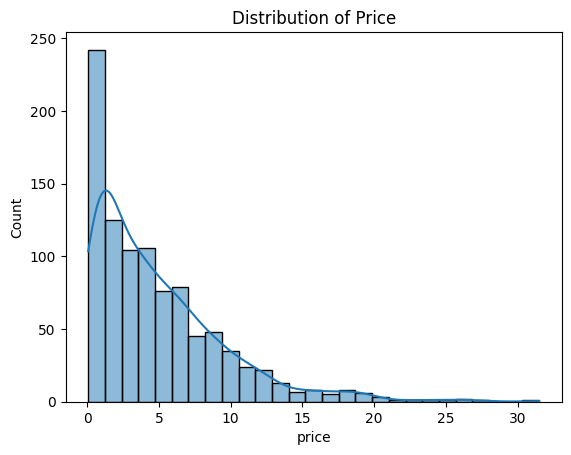

In [16]:
#Histplot

sns.histplot(df["price"],kde=True)
plt.title("Distribution of Price")
plt.show()

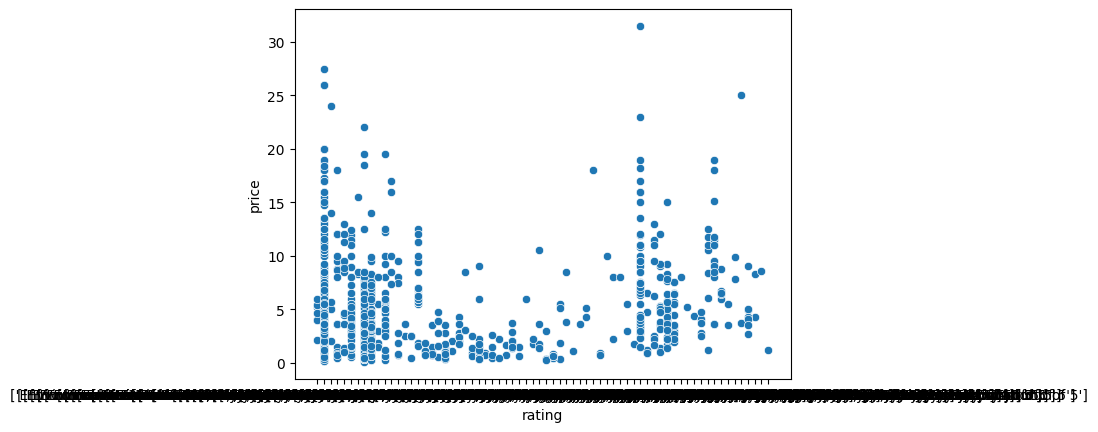

In [17]:
#Scatter plot

sns.scatterplot(x=df["rating"], y=df["price"])
plt.show()

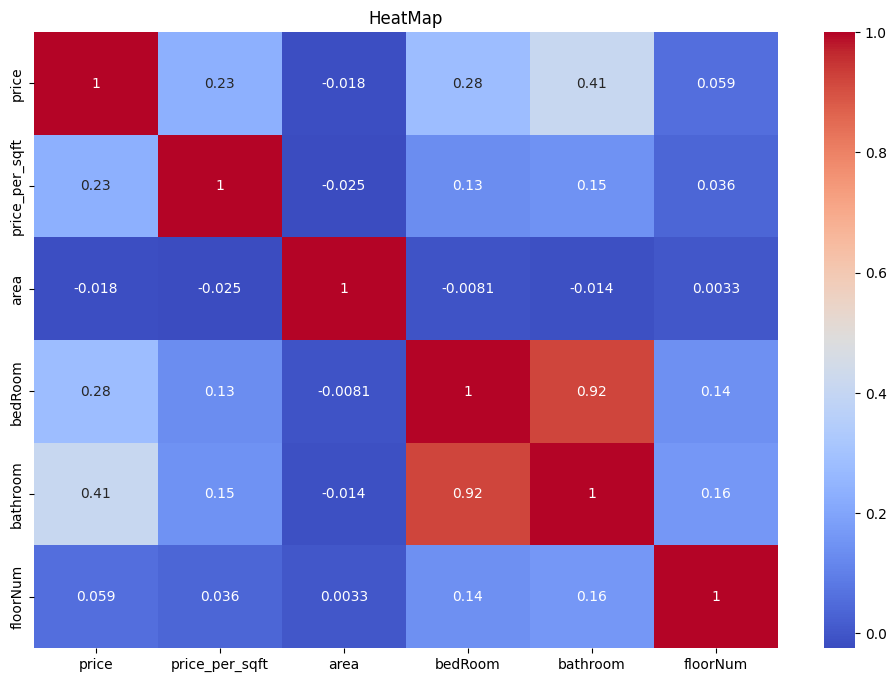

In [18]:
#HeatMap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("HeatMap")
plt.show()

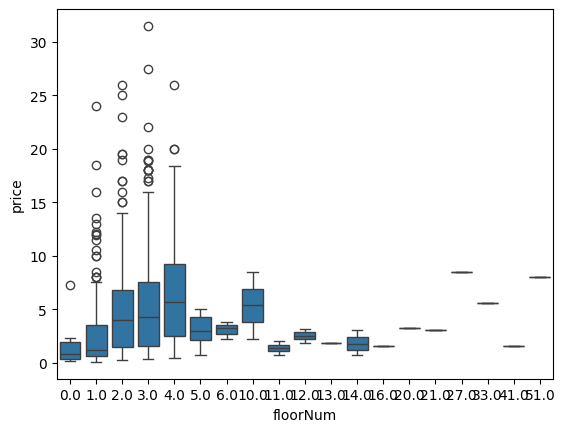

In [20]:
#Boxplot

sns.boxplot(x=df["floorNum"], y=df["price"])
plt.show()

In [21]:
#Each column name

print(df.columns)

Index(['property_name', 'property_type', 'society', 'price', 'price_per_sqft',
       'area', 'areaWithType', 'bedRoom', 'bathroom', 'balcony',
       'additionalRoom', 'address', 'floorNum', 'facing', 'agePossession',
       'nearbyLocations', 'description', 'furnishDetails', 'rating'],
      dtype='object')


In [22]:
#Select only the bedroom column using label based indexing

df.loc[:, df.columns == "bedRoom"]

,bedRoom
0,5
1,5
2,10
3,21
4,12
...,...
959,4
960,3
961,3
962,3


In [23]:
#Remove extra spaces from the column names

df.columns = df.columns.str.strip()

In [24]:
#Replacing any special type with nothing to avoid any error

cols = ["bedRoom", "bathroom", "balcony"]

for col in cols:
    df[col] = df[col].astype(str).str.replace("+", "", regex=False)
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [25]:
#filling the cols which was removed earlier

df[cols] = df[cols].fillna(df[cols].median())

--Feature Engineering

Feature engineering helps improve model performance by creating meaningful new features.

In this project:

-We created "Total rooms" by combining:

 *bedroom
 *bathroom
 *balcony
 
This gives a better representation of total space in the house.

In [26]:
df["Total_rooms"] = df["bedRoom"] + df["bathroom"] + df["balcony"]

In [27]:
#Datatypes

df[cols].head()
df[cols].dtypes

bedRoom     int64
bathroom    int64
balcony     int64
dtype: object

In [28]:
df.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,rating,Total_rooms
0,5 Bedroom House for sale in Sector 70A Gurgaon,house,bptp visionnaire,5.25,20115.0,2610.0,Plot area 290(242.48 sq.m.),5,4,3,servant room,"29b, Sector 70A Gurgaon, Gurgaon, Haryana",3.0,North-East,0 to 1 Year Old,"['Good Earth City Center 2', 'Kunskapsskolan I...",Do you wish to buy an independent house in sec...,"['1 Wardrobe', '1 Fan', '1 Exhaust Fan', '1 Ge...","['Environment5 out of 5', 'Lifestyle4 out of 5...",12
1,5 Bedroom House for sale in Sector 21A Faridabad,house,independent,5.70,105751.0,539.0,Plot area 539(50.07 sq.m.),5,4,2,"store room,pooja room,servant room","Sector 21A Faridabad, Gurgaon, Haryana",2.0,UnKnown,5 to 10 Year Old,UnKnown,"Hi, we have an independent house/villa availab...","['1 Water Purifier', '5 Fan', '1 Exhaust Fan',...","['Environment5 out of 5', 'Lifestyle5 out of 5...",11
2,10 Bedroom House for sale in Sushant Lok Phase 1,house,independent,2.10,38251.0,549.0,Plot area 61(51 sq.m.),10,10,3,servant room,"Sushant Lok Phase 1, Gurgaon, Haryana",5.0,West,0 to 1 Year Old,"['Sector 42-43 metro station', 'Huda city cent...","Monthly rental income is rs1,40,000/- Best opt...","['10 Bed', '3 Fan', '10 Geyser', '2 Light', 'N...","['Environment5 out of 5', 'Lifestyle5 out of 5...",23
3,21 Bedroom House for sale in Sector 54 Gurgaon,house,independent,5.00,43066.0,1161.0,Plot area 129(107.86 sq.m.),21,21,3,servant room,"Sector 54 Gurgaon, Gurgaon, Haryana",5.0,North,1 to 5 Year Old,"['Sector 53-54 metro station', 'Sector 54 chow...","129 sq yd plot size. 5 floors built up , fully...","['1 Water Purifier', '21 Fan', '1 Fridge', '1 ...","['Environment4 out of 5', 'Lifestyle5 out of 5...",45
4,12 Bedroom House for sale in Sushant Lok Phase 1,house,independent,3.00,53763.0,558.0,Plot area 62(51.84 sq.m.),12,12,3,others,"1228, Sushant Lok Phase 1, Gurgaon, Haryana",5.0,West,Within 6 months,"['Sector 42-43 metro station', 'Huda city cent...",Best for investment purpose. Fully furnished b...,"['1 Water Purifier', '1 Fridge', '12 Fan', '1 ...","['Environment5 out of 5', 'Lifestyle5 out of 5...",27


In [29]:
Y=df["price"]

In [30]:
#Delete any unneccesary columns

X=df.drop(["property_name","society","additionalRoom","areaWithType","address","facing","nearbyLocations","description","furnishDetails","rating","agePossession","property_type"], axis=1, errors="ignore")

In [31]:
X.head()

,price,price_per_sqft,area,bedRoom,bathroom,balcony,floorNum,Total_rooms
0,5.25,20115.0,2610.0,5,4,3,3.0,12
1,5.70,105751.0,539.0,5,4,2,2.0,11
2,2.10,38251.0,549.0,10,10,3,5.0,23
3,5.00,43066.0,1161.0,21,21,3,5.0,45
4,3.00,53763.0,558.0,12,12,3,5.0,27


In [32]:
#Get all categorical(object) column names

X.select_dtypes(include="object").columns

Index([], dtype='object')

In [33]:
#Convert categorical(object) into numeric columns

X = pd.get_dummies(X, drop_first=True)

In [34]:
X.head()

,price,price_per_sqft,area,bedRoom,bathroom,balcony,floorNum,Total_rooms
0,5.25,20115.0,2610.0,5,4,3,3.0,12
1,5.70,105751.0,539.0,5,4,2,2.0,11
2,2.10,38251.0,549.0,10,10,3,5.0,23
3,5.00,43066.0,1161.0,21,21,3,5.0,45
4,3.00,53763.0,558.0,12,12,3,5.0,27


In [35]:
col_to_drop=["property_name","society","additionalRoom","areaWithType","address","facing","nearbyLocations","description","furnishDetails","rating","agePossession","property_type"]

In [36]:
#Code to show before and after the columns dropped

print("Before:", df.shape)

X = df.copy()
X = X.drop(columns=col_to_drop, errors="ignore")

print("After:", X.shape)

print("Still present:", set(col_to_drop) & set(X.columns))

Before: (964, 20)
After: (964, 8)
Still present: set()


In [37]:
X.head()

,price,price_per_sqft,area,bedRoom,bathroom,balcony,floorNum,Total_rooms
0,5.25,20115.0,2610.0,5,4,3,3.0,12
1,5.70,105751.0,539.0,5,4,2,2.0,11
2,2.10,38251.0,549.0,10,10,3,5.0,23
3,5.00,43066.0,1161.0,21,21,3,5.0,45
4,3.00,53763.0,558.0,12,12,3,5.0,27


--MODEL BUILDING

We trained multiple regresssion model to compare performance:

1. Linear Regression
2. Ridge Regression
3. Random Forest

Dataset was split into training and testing sets(80-20)split.

We evaluated models using:

1. r2 Score
2. mean absolue error(MAE)
3. mean squared error(MSE)

In [38]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [39]:
#MODEL1 - Linear Regression 
lr=LinearRegression()
lr.fit(X_train,Y_train)

y_pred_lr=lr.predict(X_test)

In [40]:
#MODEL2 - Ridge Regression
ridge=Ridge(alpha=1.0)
ridge.fit(X_train,Y_train)

y_pred_ridge=ridge.predict(X_test)

In [44]:
#MODEL3 - Random Forest
rf=RandomForestRegressor(random_state=42)
rf.fit(X_train, Y_train)

y_pred_rf=rf.predict(X_test)

--MODEL EVALUATION AND COMPARISION

1. Linear Regression -Explain r2 score -Mention if underfitting or decent performance

2. Ridge Regression -Explain impact regularization -Did it improve over linear regression

3. Random Forest -Usually performs better due to non linear capacity -Mention if it gave highest r2

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [56]:
#Evalution Function
def evaluate(Y_true, y_pred):
    print("R2:", r2_score(Y_true, y_pred))
    print("MAE:", mean_absolute_error(Y_true, y_pred))
    print("MSE:", np.sqrt(mean_squared_error(Y_true, y_pred)))

In [57]:
X = df[[
    "area",
    "bedRoom",
    "bathroom",
    "balcony",
    "floorNum",
    "Total_rooms"
]]

y = df["price"]

In [67]:
#Evaluation of all three MODELS

print("Linear Regression")
lr = LinearRegression()
lr.fit(X_train, Y_train)

y_pred = lr.predict(X_test)
evaluate(Y_test, y_pred_lr)

print("\n Ridge Regression")
ridge=Ridge(alpha=1.0)
ridge.fit(X_train,Y_train)

Y_pred_ridge=ridge.predict(X_test)
evaluate(Y_test, y_pred_ridge)

print("\n Random Forest Regressor")
rf=RandomForestRegressor(random_state=42)
rf.fit(X_train, Y_train)

Y_pred_rf=rf.predict(X_test)
evaluate(Y_test, y_pred_rf)

Linear Regression
R2: 0.368154146057574
MAE: 2.4586873122083692
MSE: 3.1929196084793996

 Ridge Regression
R2: 0.3681500311216237
MAE: 2.4586592365181423
MSE: 3.1929300055075753

 Random Forest Regressor
R2: 0.6294187668207185
MAE: 1.6255678176659263
MSE: 2.4452548278379584


In [68]:
#Check if the price column exists in X

print("price" in X.columns)

False


In [69]:
df.select_dtypes(include=['number']).corr()["price"].sort_values(ascending=False)

price             1.000000
bathroom          0.411020
balcony           0.404561
Total_rooms       0.387349
bedRoom           0.275929
price_per_sqft    0.232143
floorNum          0.059129
area             -0.017551
Name: price, dtype: float64

In [70]:
print(X.columns)

Index(['area', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'Total_rooms'], dtype='object')


In [71]:
#Creating an Random Forest Model and train it using training model

rf = RandomForestRegressor()
rf.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [72]:
feature_names = X_train.columns.tolist()

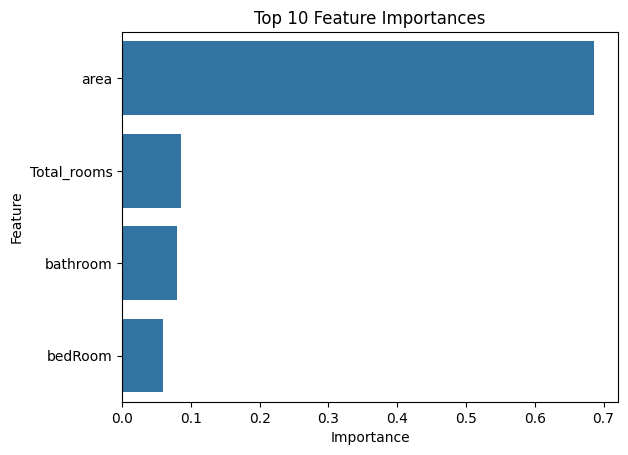

In [73]:
#Feature important plot

importances = rf.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    "Importance", ascending=False
).head(4)

sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Top 10 Feature Importances")
plt.show()

--CONCLUSION

In this project, I performed:

1. Data cleaning and feature engineering.
2. Explored relationship betweeen variables.
3. Trained and compared multiple regression models.
4. Feature important plot.